# Dependencies

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Data Loading

In [54]:
def txt_to_pd(file_path):
    """
    Load data from a .txt file and convert into a pandas DataFrame
    Args: 
        file_path (string): Path location of the file to be converted
    Returns:
        df (DataFrame): converted dataframe with index set to "Unit Number"
    """
    
    delimiter = " "

    df = pd.read_csv(file_path, 
               delimiter=delimiter, 
               header=None,
               encoding='utf-8')
    df = df.dropna(axis=1)
    df.columns = ["Unit Number", "Time, in cycles", "Operational Setting 1", "Operational Setting 2", "Operational Setting 3", "Sensor Measurement 1",
              "Sensor Measurement 2", "Sensor Measurement 3", "Sensor Measurement 4", "Sensor Measurement 5", "Sensor Measurement 6", "Sensor Measurement 7", 
              "Sensor Measurement 8", "Sensor Measurement 9", "Sensor Measurement 10", "Sensor Measurement 11", "Sensor Measurement 12", "Sensor Measurement 13", 
              "Sensor Measurement 14", "Sensor Measurement 15", "Sensor Measurement 16", "Sensor Measurement 17", "Sensor Measurement 18", "Sensor Measurement 19", 
              "Sensor Measurement 20", "Sensor Measurement 21"]
    df = df.set_index("Unit Number")
    return df

In [55]:
# Load training and test data
train = txt_to_pd("data/Challenge_Data/train.txt")
test = txt_to_pd("data/Challenge_Data/test.txt")

In [56]:
train.head()

,"Time, in cycles",Operational Setting 1,Operational Setting 2,Operational Setting 3,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,...,Sensor Measurement 12,Sensor Measurement 13,Sensor Measurement 14,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21
Unit Number,,,,,,,,,,,,,,,,,,,,,
1,1,10.0047,0.2501,20.0,489.05,604.13,1499.45,1309.95,10.52,15.49,...,372.15,2388.13,8120.83,8.6216,0.03,368,2319,100.0,28.58,17.1735
1,2,0.0015,0.0003,100.0,518.67,642.13,1584.55,1403.96,14.62,21.61,...,521.81,2388.15,8132.87,8.3907,0.03,391,2388,100.0,38.99,23.3619
1,3,34.9986,0.8401,60.0,449.44,555.42,1368.17,1122.49,5.48,8.00,...,183.26,2387.95,8063.84,9.3557,0.02,334,2223,100.0,14.83,8.8555
1,4,20.0031,0.7005,0.0,491.19,607.03,1488.44,1249.18,9.35,13.65,...,314.84,2388.07,8052.30,9.2231,0.02,364,2324,100.0,24.42,14.7832
1,5,42.0041,0.8405,40.0,445.00,549.52,1354.48,1124.32,3.91,5.71,...,130.44,2387.89,8083.67,9.2986,0.02,330,2212,100.0,10.99,6.4025


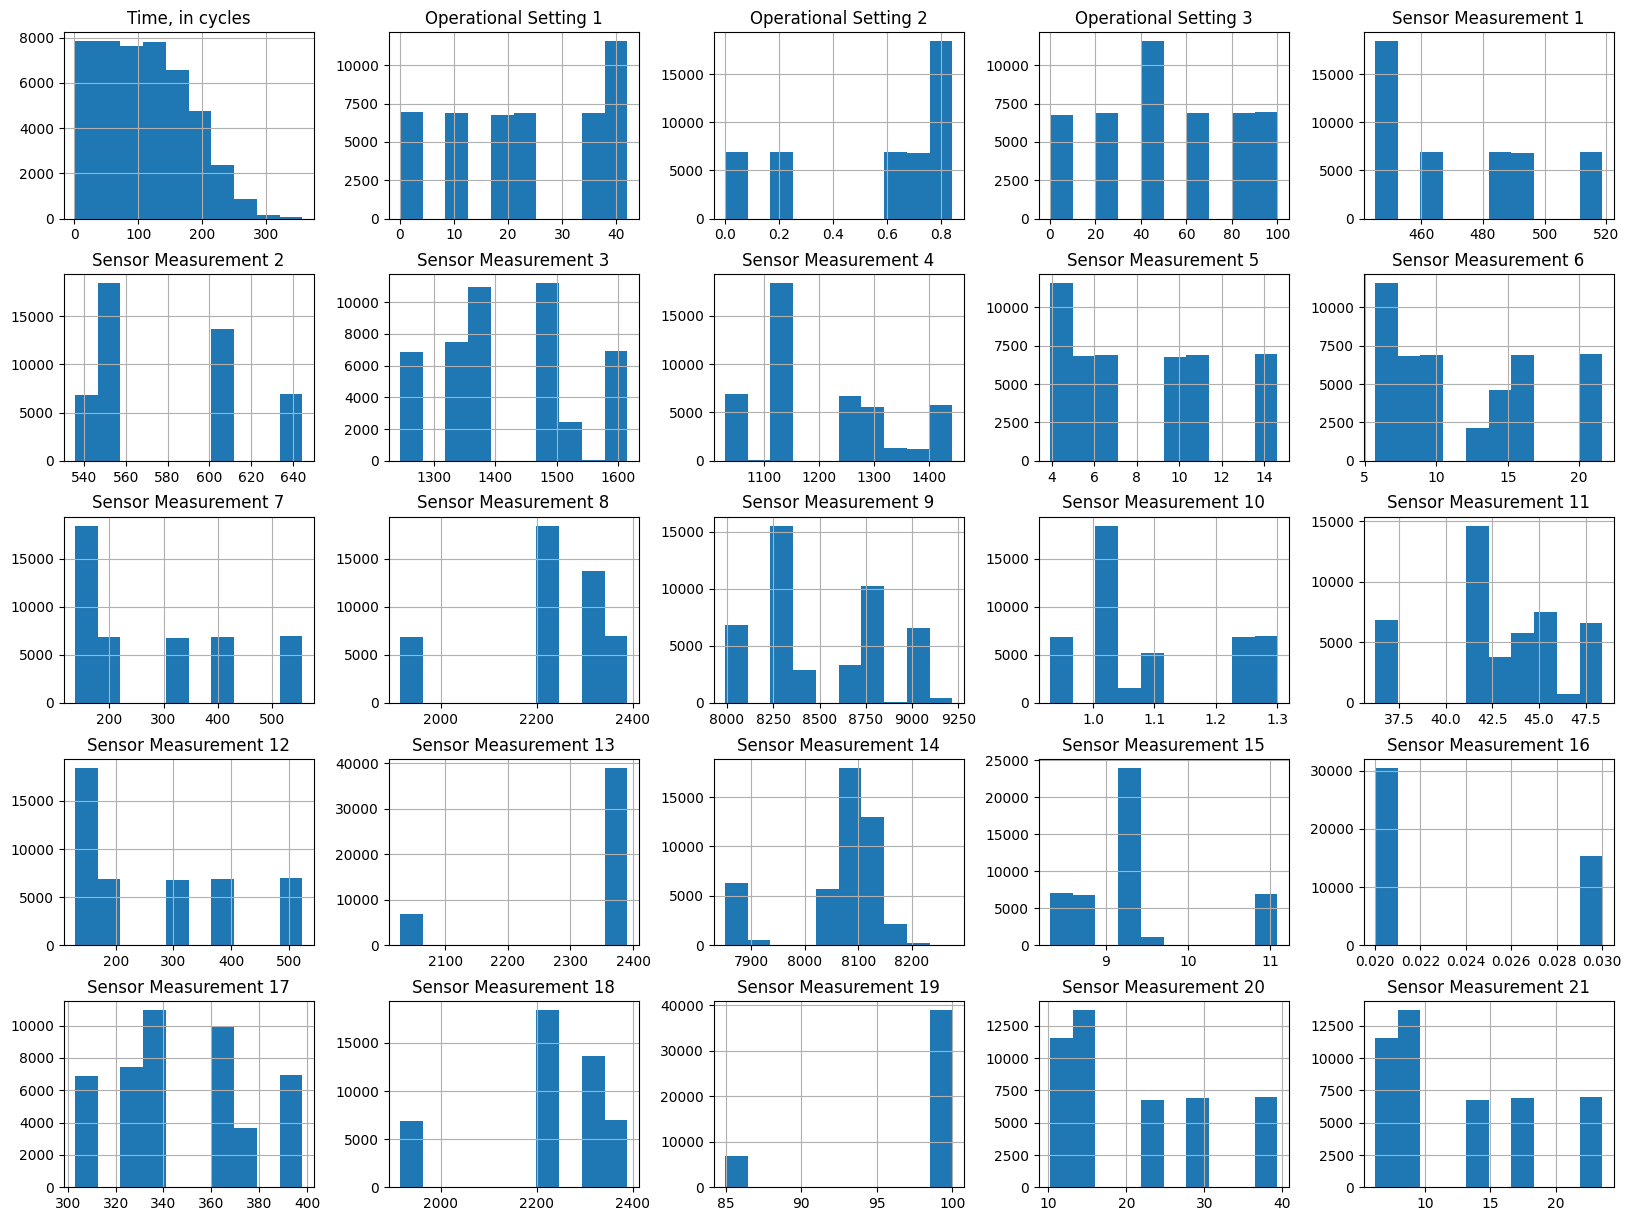

In [57]:
train.hist(bins=10, figsize=(20,15))
plt.show()

In [58]:
test.head()

,"Time, in cycles",Operational Setting 1,Operational Setting 2,Operational Setting 3,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,...,Sensor Measurement 12,Sensor Measurement 13,Sensor Measurement 14,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21
Unit Number,,,,,,,,,,,,,,,,,,,,,
1,1,0.0016,0.0002,100.0,518.67,642.88,1587.21,1412.44,14.62,21.61,...,521.44,2388.10,8124.04,8.4363,0.03,393,2388,100.00,38.97,23.3029
1,2,24.9993,0.6215,80.0,462.54,536.45,1262.64,1055.44,7.05,9.02,...,164.32,2027.95,7865.20,10.8935,0.02,308,1915,84.93,14.29,8.6686
1,3,0.0004,0.0000,100.0,518.67,642.65,1589.75,1409.54,14.62,21.61,...,521.15,2388.19,8121.12,8.4620,0.03,393,2388,100.00,38.91,23.2693
1,4,10.0034,0.2500,20.0,489.05,604.44,1499.93,1315.34,10.52,15.49,...,371.42,2388.21,8123.53,8.6815,0.03,369,2319,100.00,28.60,17.0930
1,5,0.0024,0.0011,100.0,518.67,642.74,1585.47,1408.12,14.62,21.61,...,520.86,2388.13,8118.30,8.4617,0.03,392,2388,100.00,38.82,23.3124


# Data Exploration and Pre-processing

## Data Exploration

In [59]:
# Get Actual Remaining Life
unique_list = train.index.unique().tolist()
len(unique_list)
for i in range(len(unique_list)):
    train.loc[i+1, 'Cycle Max'] = train.loc[i+1]['Time, in cycles'].max()
train['Remaining Life'] = train['Time, in cycles'] - train['Cycle Max']

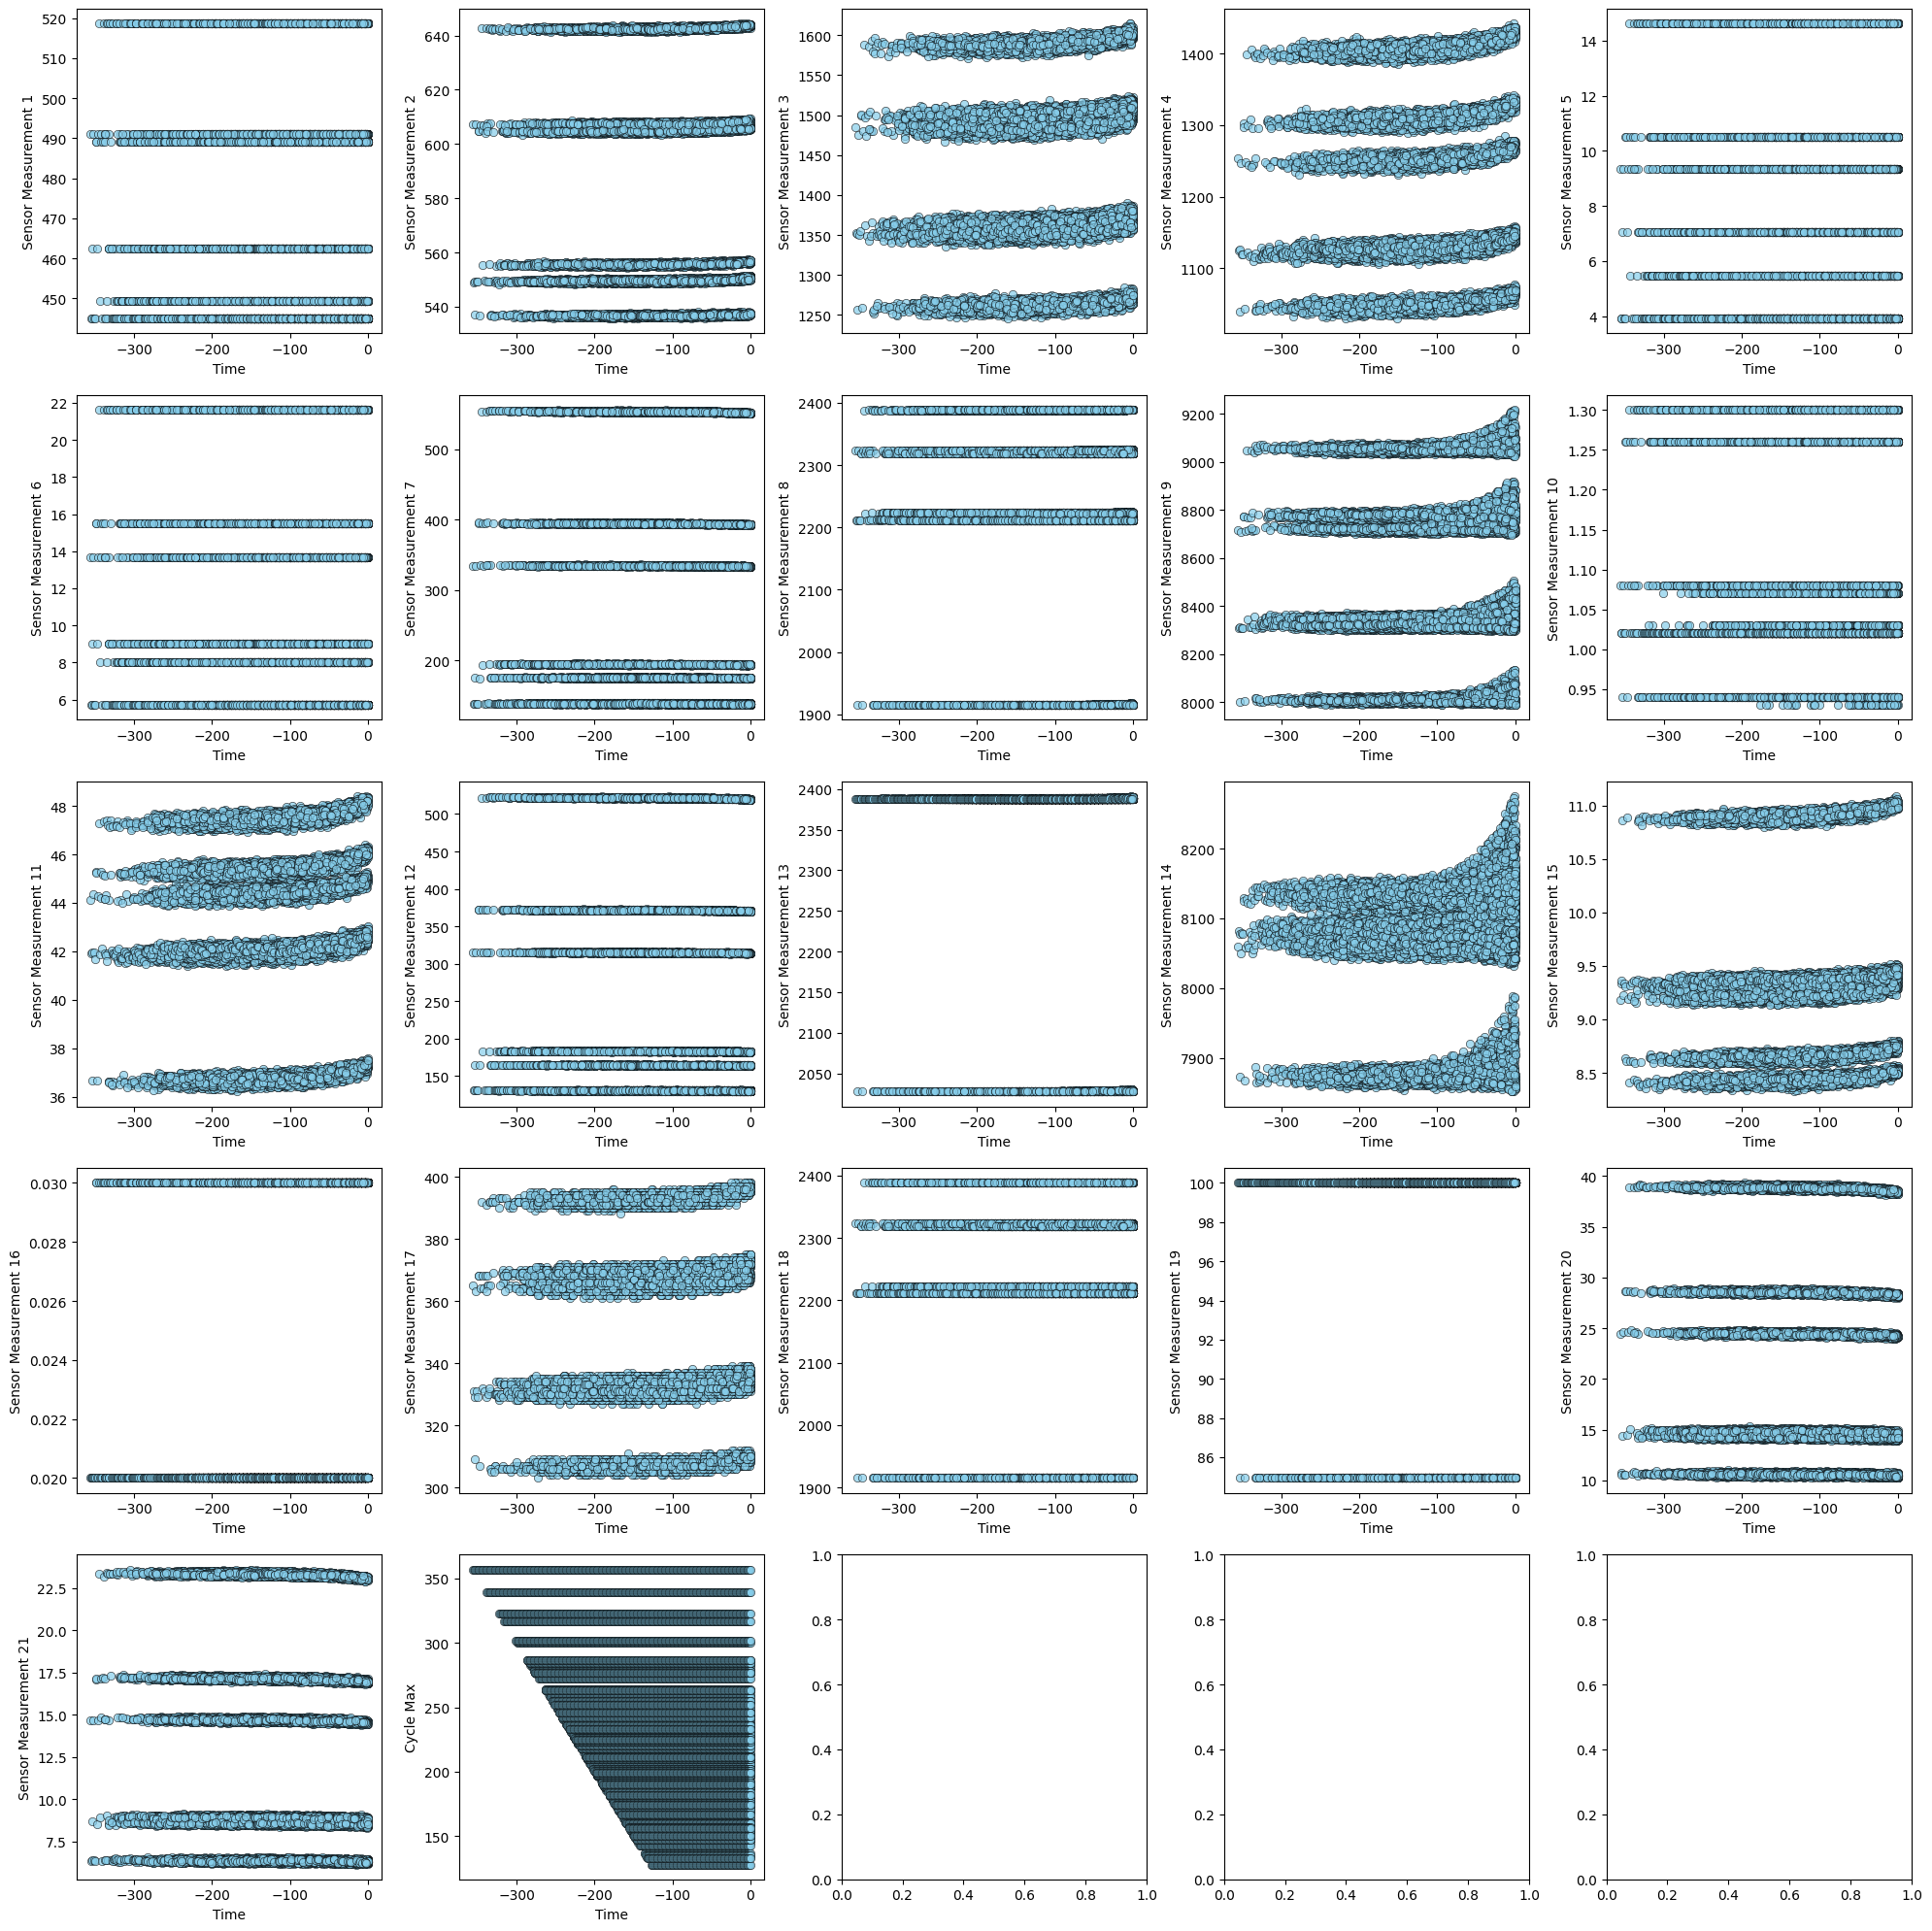

In [60]:
# Plot Remaining Life vs Sensor Measurement of all units and all clusters

fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20)) 

for i in range(len(train.columns)-5):
    # Scatter plot on the ith subplot on cluster 0
    axs[i//5, i-(i//5)*5].scatter(train['Remaining Life'], train[train.columns[i+4]], 
                   color='skyblue', alpha=0.7, edgecolors='black', linewidths=0.5)
    axs[i//5, i-(i//5)*5].set_xlabel('Time')
    axs[i//5, i-(i//5)*5].set_ylabel(train.columns[i+4])

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

In [61]:
# Get operational data
op_data = train[['Operational Setting 1', 'Operational Setting 2', 'Operational Setting 3']]

In [62]:
# # Get Operating Clusters using unsupervised learning (K-means Clustering)
# # Calculate for silhoutte score to determine optimal K-means clustering
# # Higher silhouette score = better clustering
# scores = []
# for k in range(2, 10):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(op_data)
#     score = silhouette_score(op_data, labels)
#     print("cluster " + str(k) + " - " + str(score))
#     scores.append(score)

[[1.51675295e-03 4.97670406e-04 1.00000000e+02]
 [3.50030533e+01 8.40489284e-01 6.00000000e+01]
 [1.00029627e+01 2.50502528e-01 2.00000000e+01]
 [4.20030440e+01 8.40510423e-01 4.00000000e+01]
 [2.50030126e+01 6.20516407e-01 8.00000000e+01]
 [2.00029465e+01 7.00497164e-01 8.73967565e-13]]


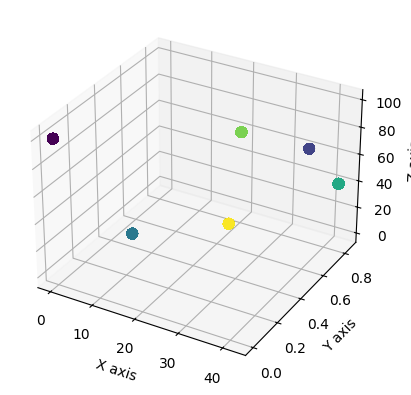

In [63]:
# Create and fit K-Means model using the optimal cluster number (k=6)
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(op_data)

# Get cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Plot k-clusters 
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Create 3D scatter plot
ax.scatter(op_data[op_data.columns[0]], op_data[op_data.columns[1]], op_data[op_data.columns[2]], c=labels, cmap='viridis', s=50)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

In [64]:
train['cluster'] = labels

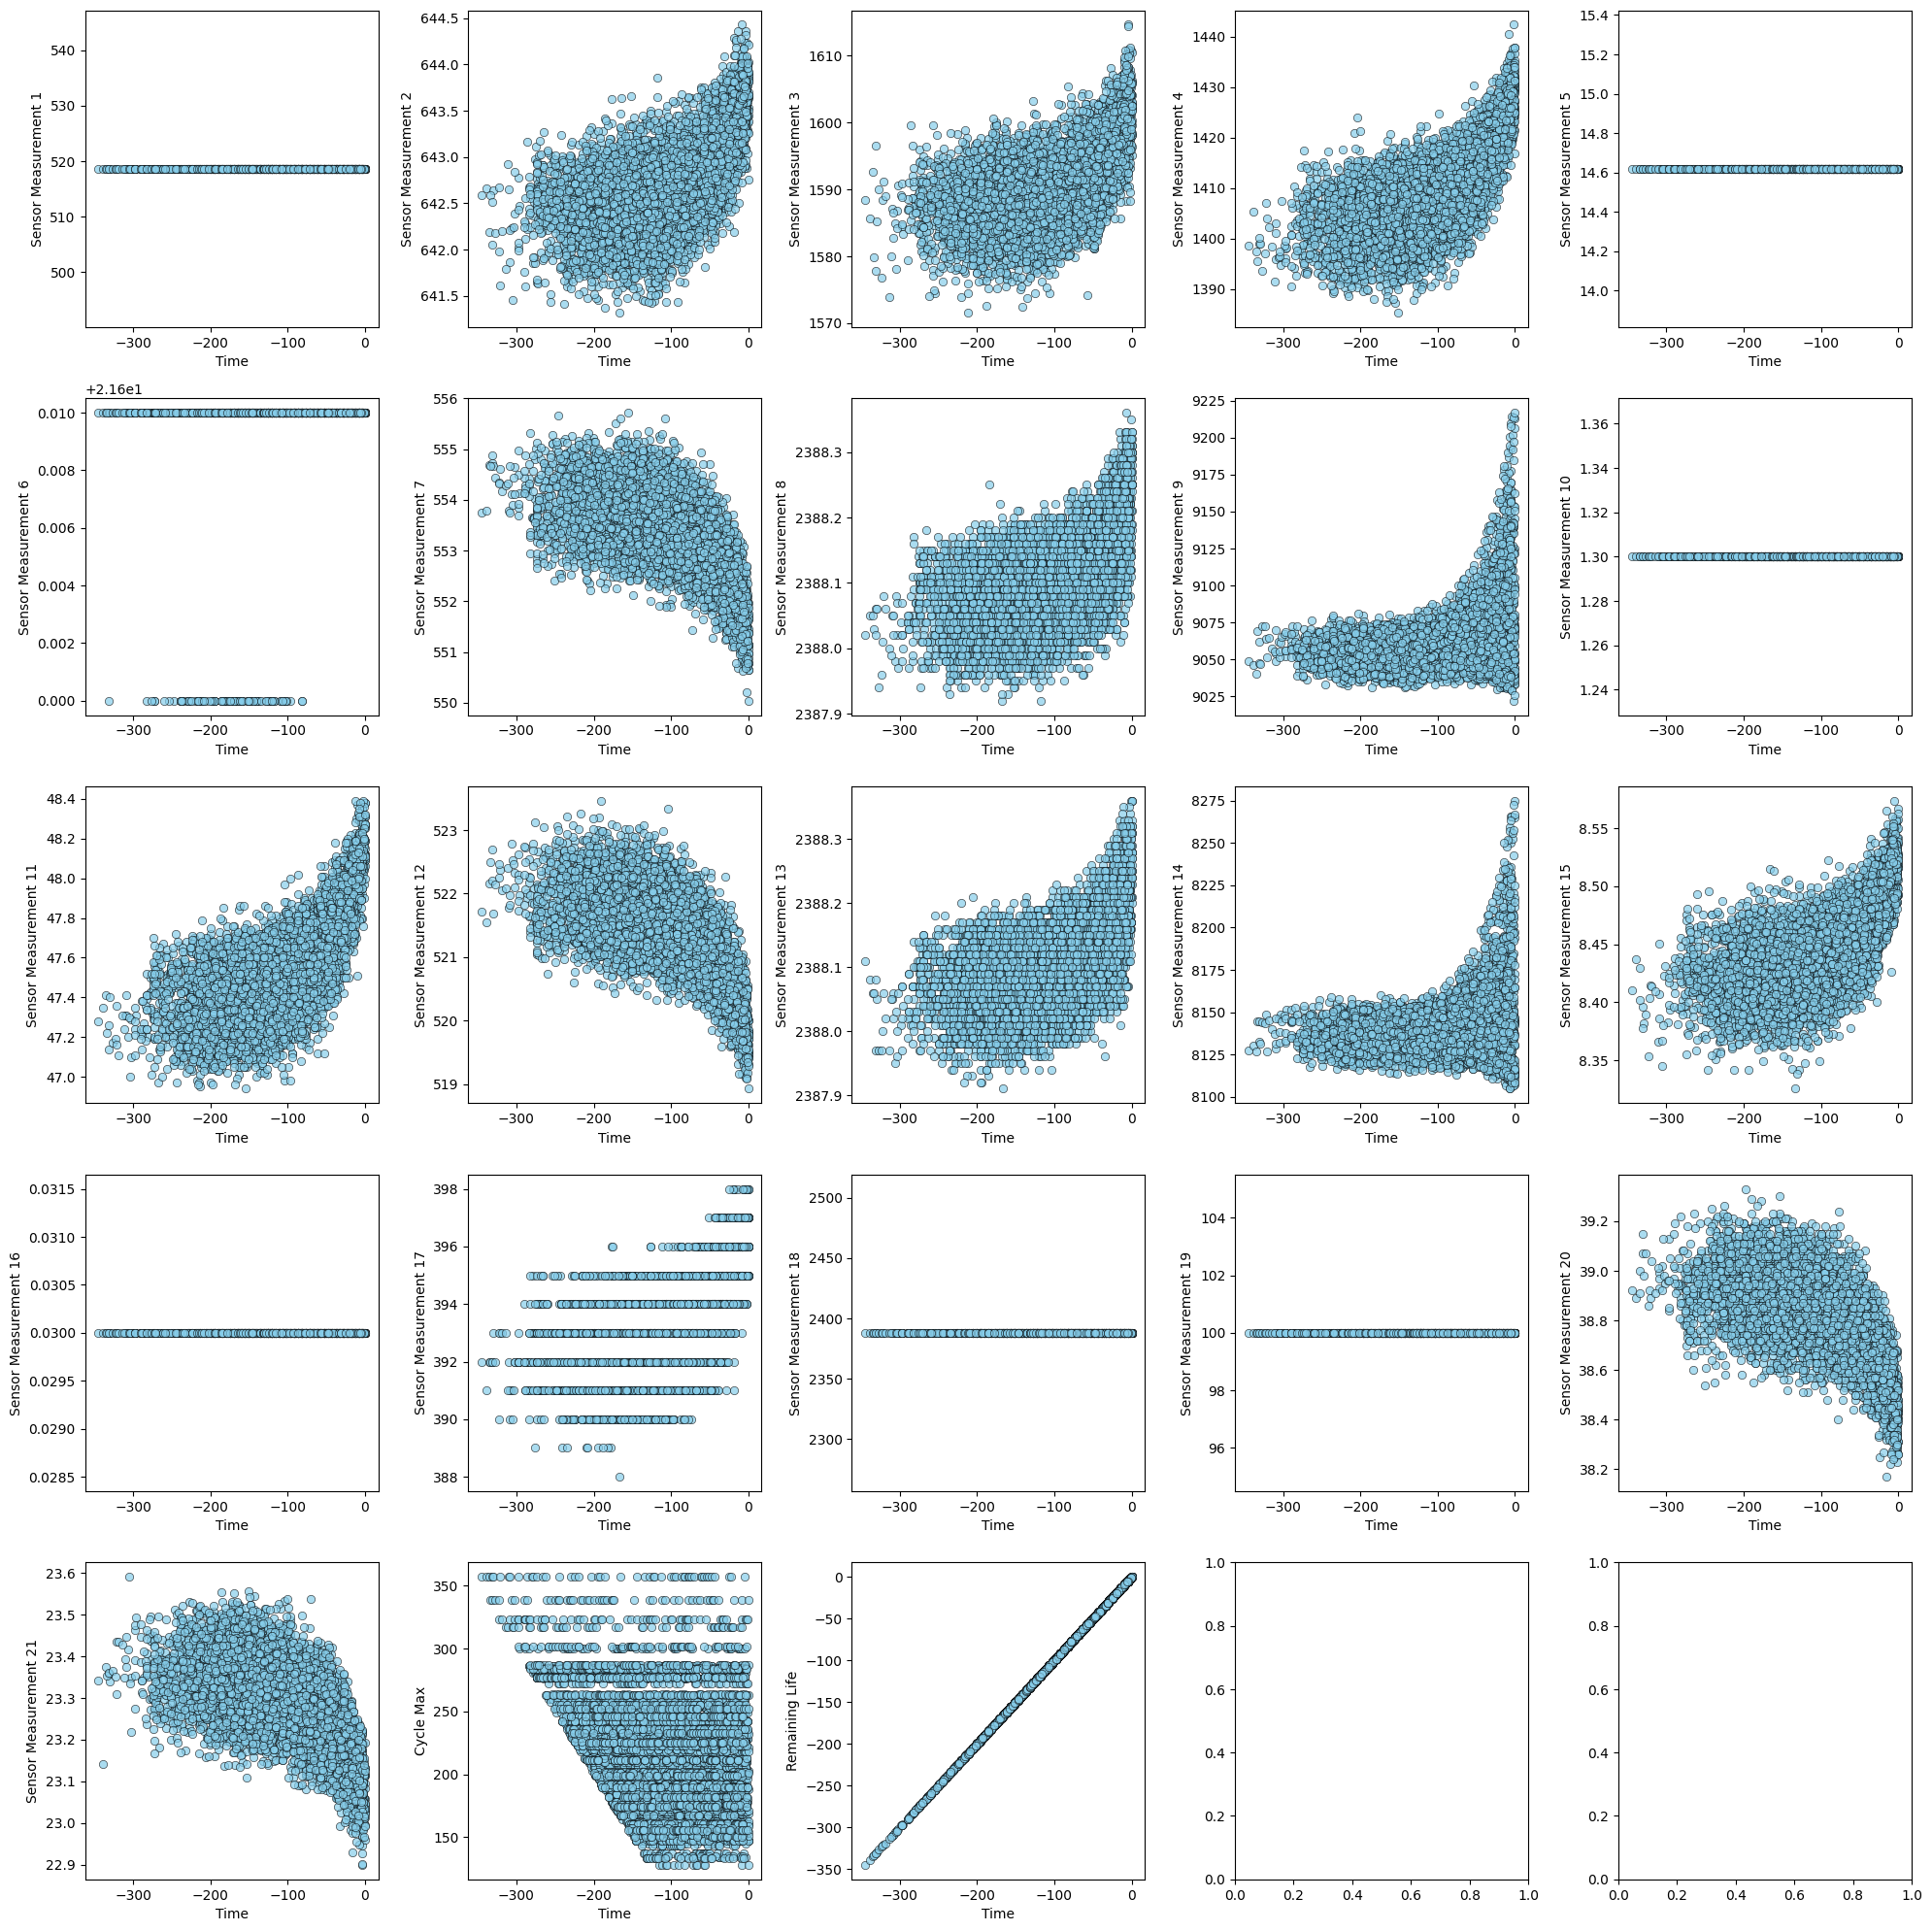

In [65]:
# Plot Remaining Life vs Sensor Measurement of all units and cluster 0

fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20)) 

for i in range(len(train.columns)-5):
    # Scatter plot on the ith subplot on cluster 0
    axs[i//5, i-(i//5)*5].scatter(train[train['cluster'] == 0]['Remaining Life'], train[train['cluster'] == 0][train.columns[i+4]], 
                   color='skyblue', alpha=0.7, edgecolors='black', linewidths=0.5)
    axs[i//5, i-(i//5)*5].set_xlabel('Time')
    axs[i//5, i-(i//5)*5].set_ylabel(train.columns[i+4])

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

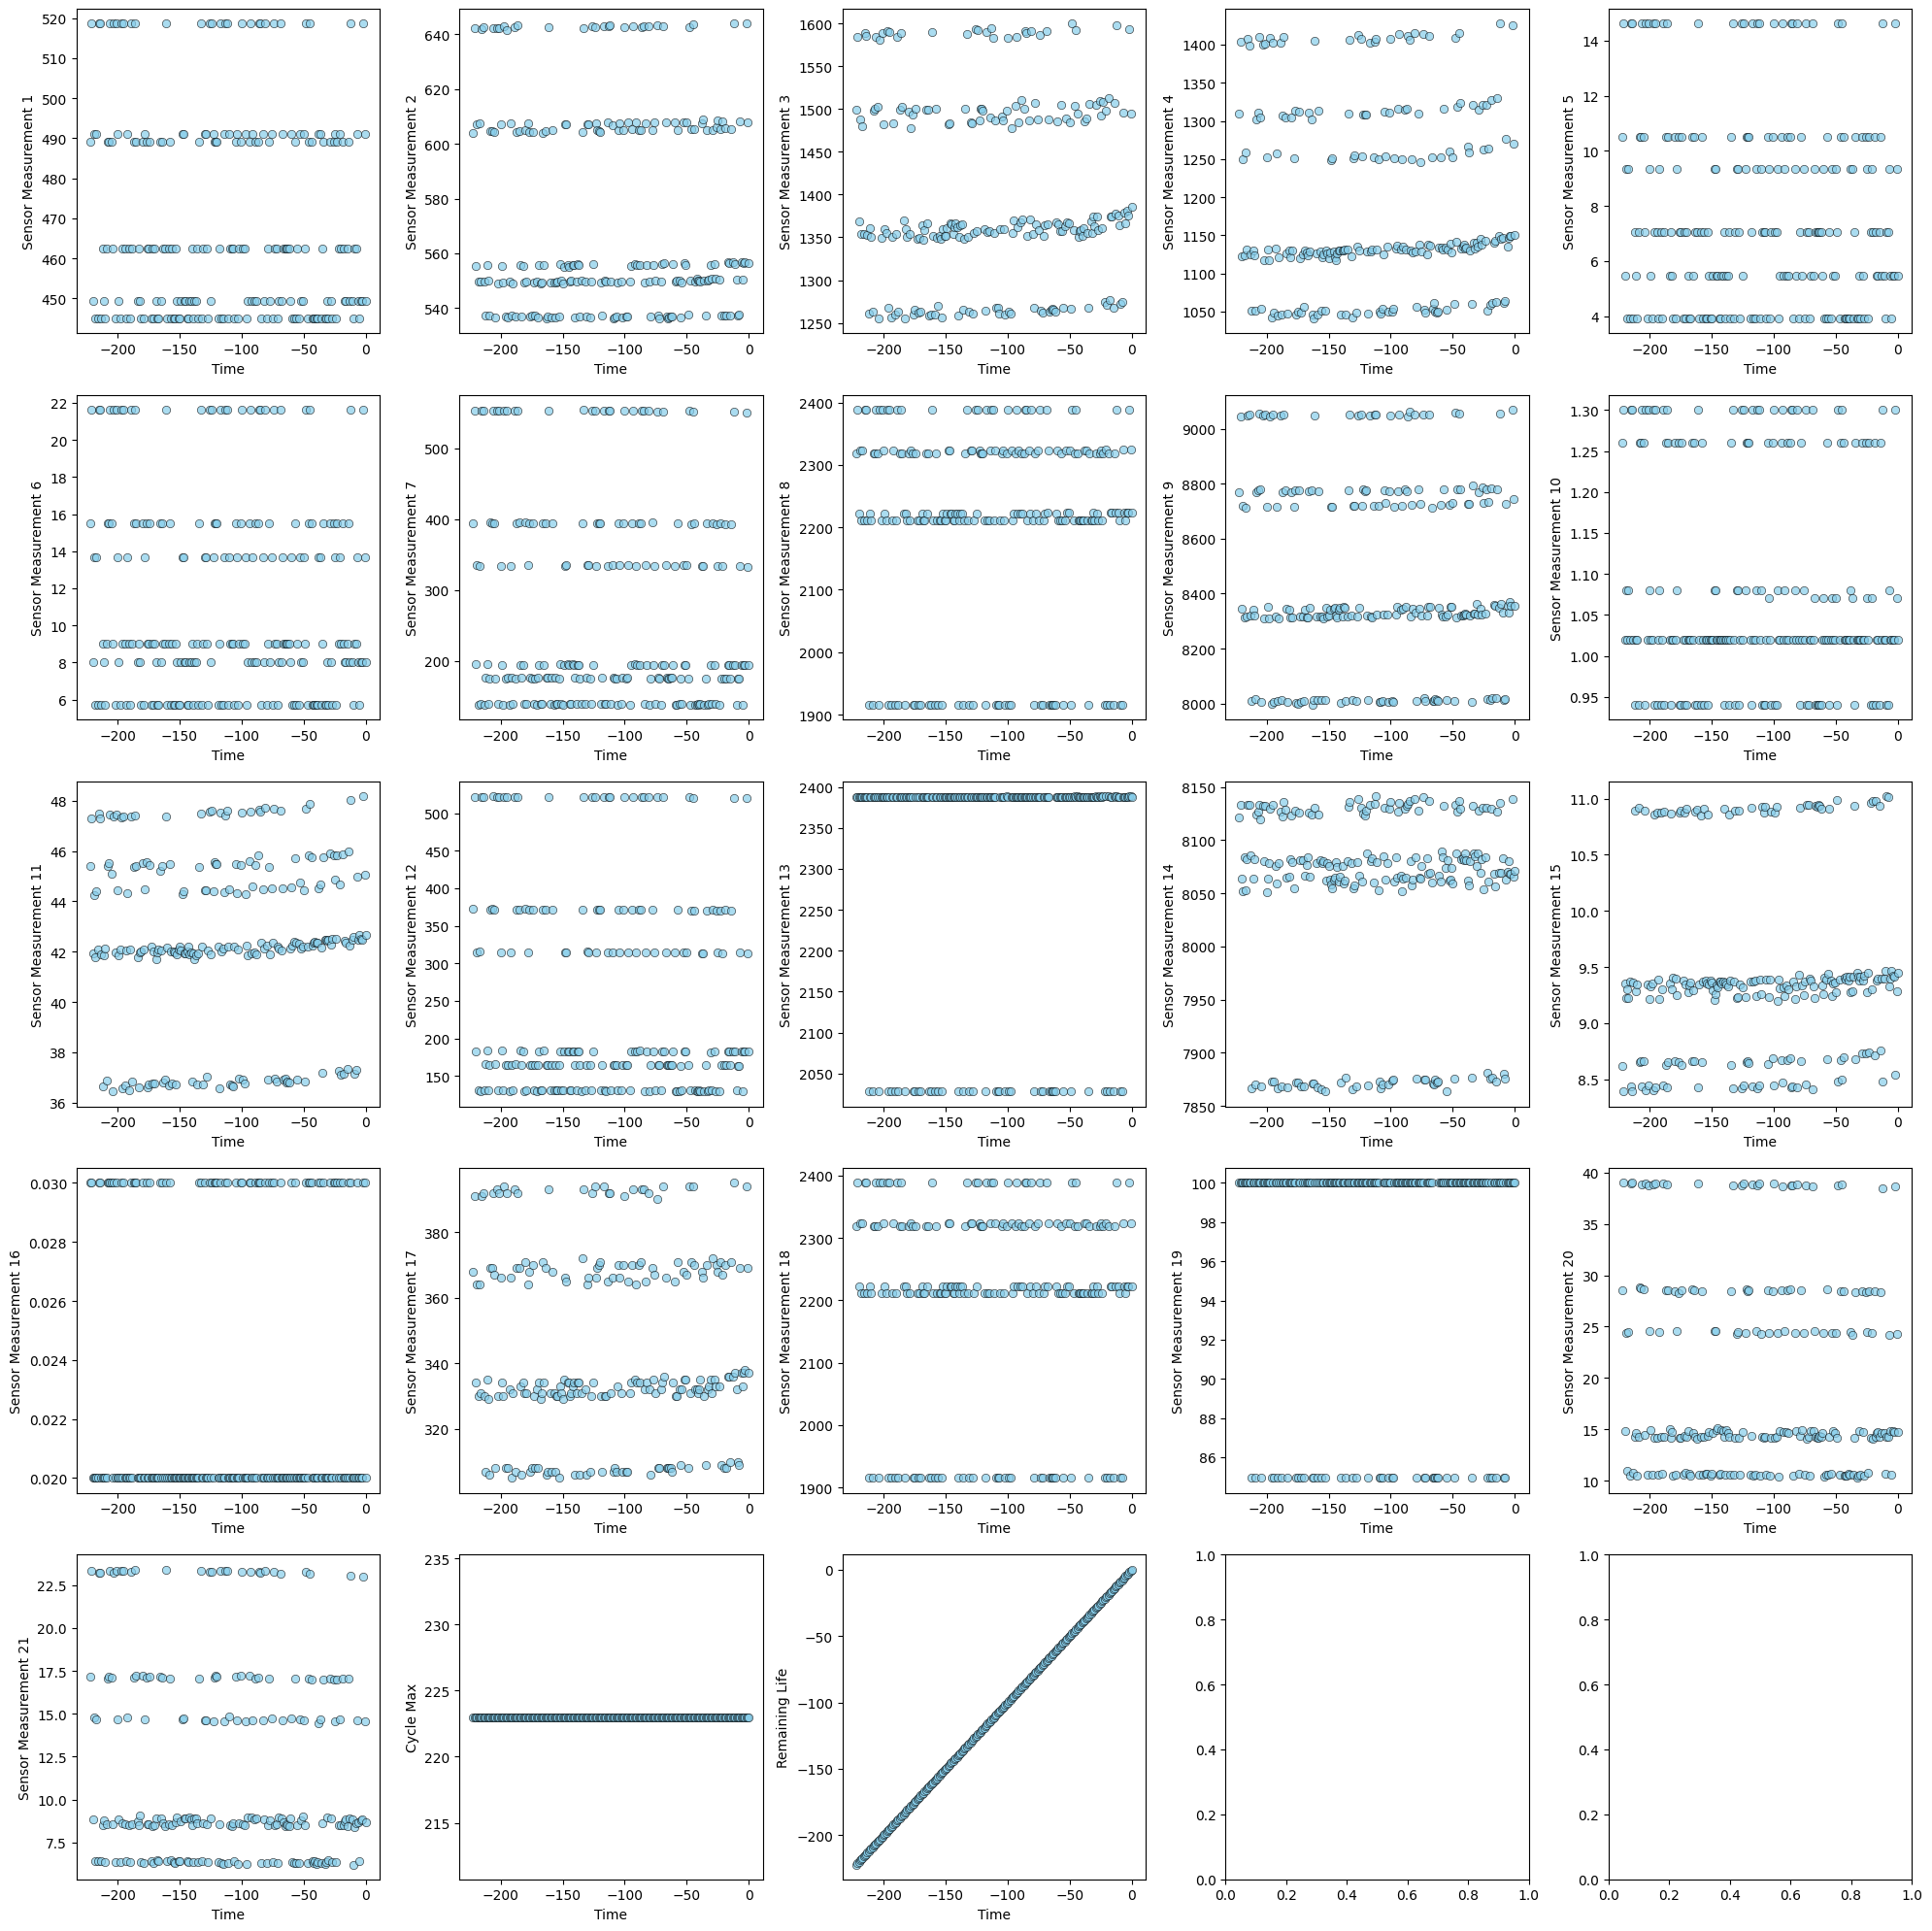

In [66]:
# Plot Remaining Life vs Sensor Measurement of Unit 1 and all clusters

fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20)) 

for i in range(len(train.columns)-5):
    # Scatter plot on the ith subplot on cluster 0
    axs[i//5, i-(i//5)*5].scatter(train.loc[1]['Remaining Life'], train.loc[1][train.columns[i+4]], 
                   color='skyblue', alpha=0.7, edgecolors='black', linewidths=0.5)
    axs[i//5, i-(i//5)*5].set_xlabel('Time')
    axs[i//5, i-(i//5)*5].set_ylabel(train.columns[i+4])

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

## Data preprocessing

In [67]:
# Split data set into training and test sets
# Apply random seed to allow repetition of output
train_set, val_set = train_test_split (train, test_size=0.2, random_state=23)

In [68]:
# Apply Standard Scaler by cluster to transform the scaling of different features into similar scales.
unique_clusters = train_set['cluster'].unique().tolist()

cluster_mean= pd.DataFrame()
cluster_std= pd.DataFrame()

for i in range(len(unique_clusters)):
    cluster_mean['Cluster ' + str(i+1)] = train_set[train_set['cluster'] == i].mean()
    cluster_std['Cluster ' + str(i+1)] = train_set[train_set['cluster'] == i].std()

cluster_mean = cluster_mean.transpose()
cluster_std = cluster_std.transpose()


In [69]:
# Get normalized sensor measurement - training set
train_scaled_temp= pd.DataFrame()
train_scaled= pd.DataFrame()

for i in range(len(unique_clusters)):
    train_scaled_temp = (train_set[train_set['cluster'] == i] - cluster_mean.loc['Cluster ' + str(i+1)]) / cluster_std.loc['Cluster ' + str(i+1)]
    train_scaled_temp['Time, in cycles Reference'] = train_set[train_set['cluster'] == i]['Time, in cycles']
    train_scaled_temp['Remaining Life Reference'] = train_set[train_set['cluster'] == i]['Remaining Life']
    train_scaled_temp['Cluster Reference'] = train_set[train_set['cluster'] == i]['cluster']
    train_scaled = pd.concat([train_scaled, train_scaled_temp], axis=0)
train_scaled = train_scaled.drop(["Time, in cycles", "Operational Setting 1", "Operational Setting 2", "Operational Setting 3", 
                                  "cluster", "Cycle Max", "Remaining Life"], axis=1)
train_scaled = train_scaled.fillna(0)
train_scaled.rename(columns={'Remaining Life Reference': 'Remaining Life', 'Time, in cycles Reference': 'Time, in cycles', 
                             'Cluster Reference': 'Cluster'}, inplace=True)
train_scaled = train_scaled.sort_values(by='Time, in cycles')
train_scaled

,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,Sensor Measurement 7,Sensor Measurement 8,Sensor Measurement 9,Sensor Measurement 10,...,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21,"Time, in cycles",Remaining Life,Cluster
Unit Number,,,,,,,,,,,,,,,,,,,,,
155,-0.999909,-1.114765,-0.618672,-0.952734,0.999909,-0.706275,0.907436,-1.299316,0.061517,0.000000,...,-0.924615,-0.999909,-1.193968,0.0,0.0,0.096150,1.238548,1,-220.0,2
101,0.000000,0.355041,-0.090011,-0.987791,-0.999911,0.112539,0.668420,-0.949329,-0.330900,-0.999911,...,-0.750567,-0.999911,-0.182962,0.0,0.0,-0.099225,-0.621677,1,-225.0,0
172,0.999908,-1.379270,-2.181128,-0.779002,-0.999908,-0.172709,-0.787307,-0.454483,-0.310054,-0.171580,...,-0.548498,0.999908,-0.923607,0.0,0.0,0.013864,-0.785990,1,-221.0,1
131,0.000000,-0.202732,-2.828037,-1.440901,-0.999911,0.112539,1.391319,-1.972640,0.156902,-0.999911,...,-0.469948,-0.999911,-0.856107,0.0,0.0,0.130507,0.724893,1,-262.0,0
106,0.000000,0.357935,-0.087494,-1.095263,0.999946,0.850396,-0.107674,-1.215773,-1.233854,-0.150797,...,-0.217604,0.000000,-0.092995,0.0,0.0,-2.082435,-0.511013,1,-188.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.000000,1.448262,1.408972,3.577679,0.999946,0.850396,-0.830847,2.211105,2.688977,6.630708,...,-0.160812,0.000000,2.033998,0.0,0.0,-1.245921,-1.644975,350,-7.0,3
5,0.000000,2.648110,1.280700,2.052392,-0.999911,0.112539,-1.791769,1.389667,2.354553,-0.999911,...,1.923562,-0.999911,1.163329,0.0,0.0,-2.166807,-2.430174,352,-5.0,0
5,0.000000,2.470443,1.335203,2.057087,0.999946,0.850396,0.005321,2.079302,2.739637,-0.150797,...,2.029732,0.000000,3.451992,0.0,0.0,2.193084,-1.076428,353,-4.0,3


In [70]:
# Get normalized sensor measurement - validation set


In [71]:
# Convert training and test dataset into x and y

xtrain = train_scaled.drop(["Remaining Life"], axis=1)
ytrain = train_scaled["Remaining Life"]

# xtest = val_scaled.drop(["Remaining Life"], axis=1)
# ytest = val_scaled["Remaining Life"]

In [72]:
# Trandability analysis


# Construct Asset Health Indicator

In [73]:
xtrain

,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,Sensor Measurement 7,Sensor Measurement 8,Sensor Measurement 9,Sensor Measurement 10,...,Sensor Measurement 14,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21,"Time, in cycles",Cluster
Unit Number,,,,,,,,,,,,,,,,,,,,,
155,-0.999909,-1.114765,-0.618672,-0.952734,0.999909,-0.706275,0.907436,-1.299316,0.061517,0.000000,...,-0.023386,-0.924615,-0.999909,-1.193968,0.0,0.0,0.096150,1.238548,1,2
101,0.000000,0.355041,-0.090011,-0.987791,-0.999911,0.112539,0.668420,-0.949329,-0.330900,-0.999911,...,-0.383396,-0.750567,-0.999911,-0.182962,0.0,0.0,-0.099225,-0.621677,1,0
172,0.999908,-1.379270,-2.181128,-0.779002,-0.999908,-0.172709,-0.787307,-0.454483,-0.310054,-0.171580,...,-0.244412,-0.548498,0.999908,-0.923607,0.0,0.0,0.013864,-0.785990,1,1
131,0.000000,-0.202732,-2.828037,-1.440901,-0.999911,0.112539,1.391319,-1.972640,0.156902,-0.999911,...,0.733649,-0.469948,-0.999911,-0.856107,0.0,0.0,0.130507,0.724893,1,0
106,0.000000,0.357935,-0.087494,-1.095263,0.999946,0.850396,-0.107674,-1.215773,-1.233854,-0.150797,...,-1.193420,-0.217604,0.000000,-0.092995,0.0,0.0,-2.082435,-0.511013,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.000000,1.448262,1.408972,3.577679,0.999946,0.850396,-0.830847,2.211105,2.688977,6.630708,...,2.147193,-0.160812,0.000000,2.033998,0.0,0.0,-1.245921,-1.644975,350,3
5,0.000000,2.648110,1.280700,2.052392,-0.999911,0.112539,-1.791769,1.389667,2.354553,-0.999911,...,2.482068,1.923562,-0.999911,1.163329,0.0,0.0,-2.166807,-2.430174,352,0
5,0.000000,2.470443,1.335203,2.057087,0.999946,0.850396,0.005321,2.079302,2.739637,-0.150797,...,2.656626,2.029732,0.000000,3.451992,0.0,0.0,2.193084,-1.076428,353,3


In [74]:
# # Plot Remaining Life vs Normalised Sensor Measurement of all units

# fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(20, 20)) 
# cmap = plt.get_cmap('tab10')  # 'tab10' has 10 distinct colors
# colors = [cmap(i) for i in range(6)]  # get first 6 colors

# # for i in range(len(train_scaled.columns)-1):
# for i in range(4):
#     # Scatter plot on the ith subplot on cluster 0
#     for j in range(len(unique_clusters)):
#         axs[i].plot(xtrain[xtrain['Cluster']==j]['Time, in cycles'], xtrain[xtrain['Cluster']==j][xtrain.columns[i]], 
#                        color=colors[j], alpha=0.7)
#         # axs[i].scatter(ytrain[xtrain['Cluster']==j], xtrain[xtrain['Cluster']==j][xtrain.columns[i]], 
#         #        color=colors[j], alpha=0.7, edgecolors='black', linewidths=0.5)
#         axs[i].set_xlabel('Time, in cycles')
#         axs[i].set_ylabel(train_scaled.columns[i])

# # Adjust layout to prevent overlapping titles/labels
# plt.tight_layout()

In [75]:
xtrain = train_scaled.drop(["Remaining Life", "Time, in cycles", "Cluster"], axis=1)


In [76]:
# Linear Regression Basic Implementation 
model = LinearRegression()
slope = []

for column in xtrain.columns:
    x_sensor = xtrain[[column]]
    model.fit(x_sensor, ytrain)
    slope.append((model.coef_[0], column))
    print(column, model.coef_[0])
slope = sorted(slope, reverse=True)[:5]
selected_sensors = [i[1] for i in slope]
selected_sensors
# # Predict on test set
# y_pred = model.predict(xtest)

Sensor Measurement 1 0.9421317427952297
Sensor Measurement 2 38.424390923490236
Sensor Measurement 3 38.05253518206037
Sensor Measurement 4 45.20707329238423
Sensor Measurement 5 -0.5661534479935255
Sensor Measurement 6 23.260014651089154
Sensor Measurement 7 -30.684214485350594
Sensor Measurement 8 28.996656826176917
Sensor Measurement 9 26.521454679472942
Sensor Measurement 10 -2.733932991125512
Sensor Measurement 11 47.25565645903
Sensor Measurement 12 -32.55270184835519
Sensor Measurement 13 29.19681073121241
Sensor Measurement 14 20.408717602562877
Sensor Measurement 15 44.085459775005745
Sensor Measurement 16 7.796386350132605
Sensor Measurement 17 39.72898475389761
Sensor Measurement 18 0.0
Sensor Measurement 19 0.0
Sensor Measurement 20 -29.060267934645566
Sensor Measurement 21 -29.54910432601816


['Sensor Measurement 11',
 'Sensor Measurement 4',
 'Sensor Measurement 15',
 'Sensor Measurement 17',
 'Sensor Measurement 2']

In [77]:
# # Plot Remaining Life vs Normalised Sensor Measurement of all units

# fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(20, 20)) 
# cmap = plt.get_cmap('tab10')  # 'tab10' has 10 distinct colors
# colors = [cmap(i) for i in range(6)]  # get first 6 colors

# # for i in range(len(train_scaled.columns)-1):
# for i in range(4):
#     # Scatter plot on the ith subplot on cluster 0
#     for j in range(len(unique_clusters)):
#         axs[i].plot(xtrain[xtrain['Cluster']==j]['Time, in cycles'], xtrain[xtrain['Cluster']==j][xtrain.columns[i]], 
#                        color=colors[j], alpha=0.7)
#         # axs[i].scatter(ytrain[xtrain['Cluster']==j], xtrain[xtrain['Cluster']==j][xtrain.columns[i]], 
#         #        color=colors[j], alpha=0.7, edgecolors='black', linewidths=0.5)
#         axs[i].set_xlabel('Time, in cycles')
#         axs[i].set_ylabel(train_scaled.columns[i])

# # Adjust layout to prevent overlapping titles/labels
# plt.tight_layout()

In [27]:
# Linear Regression Basic Implementation 
x_sensor = xtrain[selected_sensors]
model = LinearRegression()
model.fit(x_sensor, ytrain)
y_pred = model.predict(x_sensor)
xtrain = train_scaled.drop(["Remaining Life", "Time, in cycles", "Cluster"], axis=1)

x_sensor.loc[:, "Time, in cycles"] = train_scaled["Time, in cycles"]

In [28]:
# Evaluate the model
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Slope:", model.coef_)
# print("R² score:", r2_score(y_test, y_pred))
# print("RMSE:", mean_squared_error(y_test, y_pred))

Intercept: -109.0854521696527
Coefficients: [17.75323602 13.51993142 11.16834032  8.85482948  7.22207628]
Slope: [17.75323602 13.51993142 11.16834032  8.85482948  7.22207628]


In [29]:
ytrain.shape

(36734,)

,Unit Number,Sensor Measurement 11,Sensor Measurement 4,Sensor Measurement 15,Sensor Measurement 17,Sensor Measurement 2,"Time, in cycles",max_cycle,RUL
0,155,-0.301097,-0.952734,-0.924615,-1.193968,-1.114765,1,220,219
1,101,-0.540978,-0.987791,-0.750567,-0.182962,0.355041,1,226,225
2,172,-1.332487,-0.779002,-0.548498,-0.923607,-1.379270,1,222,221
3,131,-2.172513,-1.440901,-0.469948,-0.856107,-0.202732,1,263,262
4,106,-0.026120,-1.095263,-0.217604,-0.092995,0.357935,1,189,188
...,...,...,...,...,...,...,...,...,...
36729,5,2.944851,3.577679,-0.160812,2.033998,1.448262,350,355,5
36730,5,2.178247,2.052392,1.923562,1.163329,2.648110,352,355,3
36731,5,2.647753,2.057087,2.029732,3.451992,2.470443,353,355,2
36732,5,2.058961,1.218327,1.861901,1.781867,1.349465,354,355,1


,Unit Number,Sensor Measurement 11,Sensor Measurement 4,Sensor Measurement 15,Sensor Measurement 17,Sensor Measurement 2,"Time, in cycles",max_cycle,RUL
62,1,-0.380886,-0.175689,-1.168877,-1.193968,-1.660856,1,221,220
303,1,-1.045977,-0.642238,-1.487878,-1.529253,-1.214988,2,221,219
449,1,-0.334178,-1.280892,0.546478,-0.212619,-0.924598,3,221,218
842,1,-1.596490,-0.518258,-2.135005,-0.801992,-0.459810,5,221,216
916,1,-0.277294,0.674008,-0.189313,-1.011168,-0.481193,6,221,215
...,...,...,...,...,...,...,...,...,...
22084,218,1.945170,1.861308,2.091383,1.836475,1.945729,127,133,6
22363,218,2.180887,2.540129,2.424570,1.325000,2.947461,129,133,4
22612,218,1.926232,1.849312,2.281238,0.616003,0.789523,130,133,3
22701,218,2.817523,2.900095,2.843748,2.033998,0.448795,131,133,2


In [52]:
x_sensor = xtrain[selected_sensors]
rul_per_unit = x_sensor.groupby('Unit Number')['Time, in cycles'].max().reset_index()
rul_per_unit.columns = ["Unit Number", "max_cycle"]
x_sensor = x_sensor.merge(rul_per_unit, on="Unit Number", how="left")
x_sensor["RUL"] = x_sensor["max_cycle"] - x_sensor["Time, in cycles"]
x_sensor = x_sensor.sort_values(by=['Unit Number', 'Time, in cycles'])
y_sample = x_sensor['RUL']


KeyError: 'Column not found: Time, in cycles'

In [51]:
# Linear Regression Basic Implementation 
model = LinearRegression()
model.fit(x_sensor, y_sample)
y_pred = model.predict(x_sensor)
xtrain = train_scaled.drop(["Remaining Life", "Time, in cycles", "Cluster"], axis=1)

x_sensor.loc[:, "Time, in cycles"] = train_scaled["Time, in cycles"]
x_sensor

,Sensor Measurement 11,Sensor Measurement 4,Sensor Measurement 15,Sensor Measurement 17,Sensor Measurement 2,"Time, in cycles"
Unit Number,,,,,,
155,-0.301097,-0.952734,-0.924615,-1.193968,-1.114765,1
101,-0.540978,-0.987791,-0.750567,-0.182962,0.355041,1
172,-1.332487,-0.779002,-0.548498,-0.923607,-1.379270,1
131,-2.172513,-1.440901,-0.469948,-0.856107,-0.202732,1
106,-0.026120,-1.095263,-0.217604,-0.092995,0.357935,1
...,...,...,...,...,...,...
5,2.944851,3.577679,-0.160812,2.033998,1.448262,350
5,2.178247,2.052392,1.923562,1.163329,2.648110,352
5,2.647753,2.057087,2.029732,3.451992,2.470443,353


In [50]:
y_pred = model.predict(x_sensor.drop(['Time, in cycles', 'max_cycle', 'RUL'], axis=1))


KeyError: "['max_cycle', 'RUL'] not found in axis"

ValueError: x and y must be the same size

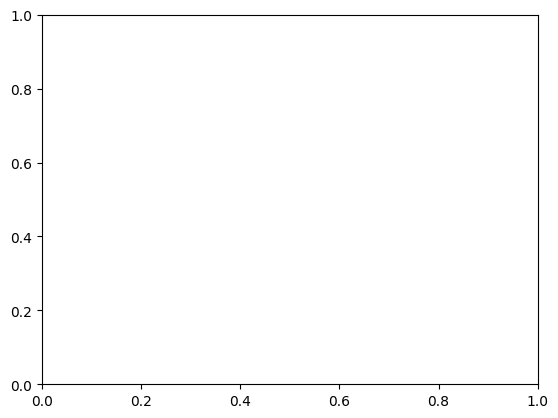

In [40]:
# Plot

plt.scatter(x_sample["Time, in cycles"], y_sample, color='blue', label='Actual')       # actual data points
plt.scatter(x_sample["Time, in cycles"], y_pred, color='red', label='LR Fit')       # actual data points
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [ ]:
# Calculate variance for each sensor
variances = xtrain.var()
threshold = 0.95
trendable_features = variances[variances > threshold].index
trendable_features

In [ ]:
health_ind = xtrain[trendable_features]
health_ind